In [ ]:
from nltk.corpus import brown
from gensim.models import Word2Vec
import matplotlib.pyplot as plt

import nltk
nltk.download('brown')
sentences = brown.sents()

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


In [ ]:
# use only first 5000 sentences
train_sentences = sentences[:5000]
print("Number of training sentences:", len(train_sentences))
print("Example sentence:", train_sentences[0])

Number of training sentences: 5000
Example sentence: ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [ ]:
# 2. Train Skip-Gram Model
model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=2,       # ignore rare words
    sg=1               # skip-gram
)
print("Model trained successfully!")

Model trained successfully!


In [ ]:
# 3. Generate Word Embeddings
embeddings = {}

for word in model.wv.index_to_key:
    embeddings[word] = model.wv[word]

print("Vocabulary size:", len(embeddings))
print("Embedding for word 'money':\n", embeddings['money'][:10])  # first 10 values

Vocabulary size: 6998
Embedding for word 'money':
 [ 0.06431736  0.14243263  0.17393021  0.06842669  0.06300627 -0.09417984
  0.20875043  0.48380437 -0.20308565 -0.33419433]


In [ ]:
# 4. Find Similar Words
query_words = ["money", "sun", "love"]

for word in query_words:
    print(f"\nTop similar words for '{word}':")
    for similar_word, score in model.wv.most_similar(word, topn=8):
        print(similar_word, score)


Top similar words for 'money':
job 0.9967114329338074
kind 0.9966418147087097
spirit 0.9963802099227905
agency 0.9961420297622681
word 0.9960851669311523
action 0.9960379600524902
once 0.9959561824798584
Berlin 0.9958430528640747

Top similar words for 'sun':
Cross 0.9966751933097839
panels 0.9966281056404114
Symphony 0.9966113567352295
pounds 0.9965696334838867
pink 0.9965478777885437
debentures 0.996497631072998
ban 0.9964376091957092
renewal 0.9964250922203064

Top similar words for 'love':
nearing 0.9969872832298279
process 0.9967122673988342
Phouma 0.9966421127319336
younger 0.9966286420822144
discuss 0.9966021776199341
An 0.9965841174125671
warm 0.9965711832046509
style 0.9965143203735352


In [ ]:
# 5. Hyperparameter Experiment
# Vector Dimension
dimensions = [50, 100, 150, 200]
scores_money = []
scores_sun = []
scores_love = []

for dim in dimensions:

    temp_model = Word2Vec(
        sentences=train_sentences,
        vector_size=dim,
        window=5,
        min_count=2,
        sg=1
    )

    scores_money.append(temp_model.wv.similarity("money", "cash"))
    scores_sun.append(temp_model.wv.similarity("sun", "star"))
    scores_love.append(temp_model.wv.similarity("love", "heart"))

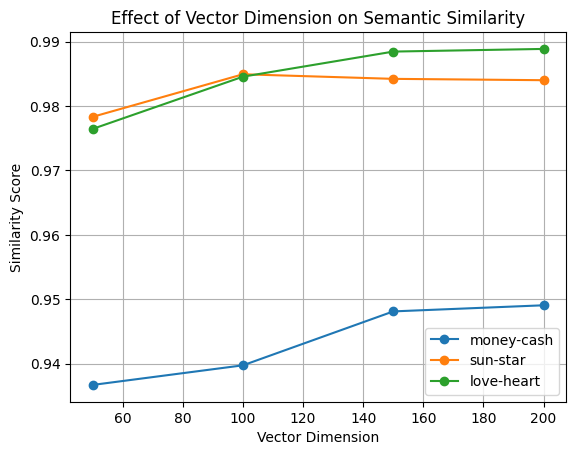

In [ ]:
# 6. Plot Results
plt.plot(dimensions, scores_money, marker='o', label="money-cash")
plt.plot(dimensions, scores_sun, marker='o', label="sun-star")
plt.plot(dimensions, scores_love, marker='o', label="love-heart")

plt.xlabel("Vector Dimension")
plt.ylabel("Similarity Score")
plt.title("Effect of Vector Dimension on Semantic Similarity")

plt.legend()
plt.grid(True)
plt.show()